In [1]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# COM763 - Advanced Machine Learning
# Bank Customer Term Deposit Prediction
# Romison Ravichandran 25026167
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Install missing libraries
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)
import pickle

print("libraries imported successfully!")

libraries imported successfully!


In [2]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~
# LOAD DATASET
# ~~~~~~~~~~~~~~~~~~~~~~~~~

# Load dataset
df = pd.read_csv('Bank_Marketing_Dataset.csv')

# Confirm it loaded
print("Dataset loaded successfully!")
print(f"Shape: {df.shape[0]} rows and {df.shape[1]} columns")
print("\nFirst 5 Rows:")
df.head(5)

Dataset loaded successfully!
Shape: 100000 rows and 45 columns

First 5 Rows:


,ClientID,Age,Gender,MaritalStatus,EducationLevel,EmploymentStatus,JobTitle,Region,SalaryCategory,CustomerSegment,...,LastContactDuration,NumContactsInCampaign,NumPrevCampaignContacts,PrevCampaignOutcome,CallResponseScore,DaysSinceLastContact,PreviousYearDeposit,MarketingScore,ResponsePropensity,TermDepositSubscribed
0,1,46,Male,Divorced,Secondary,Employed,Services,East,Mid,Mass,...,343,4,1,Failure,25.07,475,0,1.7179,0.21,0
1,2,39,Female,Married,Secondary,Self-employed,Blue-collar,Central,Low,Premium,...,198,2,0,Nonexistent,29.11,-1,0,1.6803,0.46,1
2,3,48,Male,Married,Secondary,Self-employed,Services,South,Mid,Mass,...,177,4,4,Failure,15.76,318,0,1.0510,0.22,1
3,4,59,Female,Married,Secondary,Employed,Student,South,Low,Mass,...,132,1,1,Success,40.06,819,0,1.5676,0.30,0
4,5,38,Male,Married,Tertiary,Employed,Retired,North,Low,Mass,...,376,4,1,Failure,26.51,362,0,1.2918,0.33,0


In [3]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# EXPLORATORY DATA ANALYSIS (EDA)
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# ~~~ Structure ~~~
print("=" * 50)
print("DATASET SHAPE")
print("=" * 50)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 50)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 50)
print(df.dtypes)

DATASET SHAPE
Rows: 100000
Columns: 45

COLUMN NAMES AND DATA TYPES
ClientID                      int64
Age                           int64
Gender                       object
MaritalStatus                object
EducationLevel               object
EmploymentStatus             object
JobTitle                     object
Region                       object
SalaryCategory               object
CustomerSegment              object
AnnualIncome                float64
NetWorth                    float64
CreditScore                   int64
CreditLimit                 float64
RiskRating                   object
AccountLengthYears            int64
TenureWithBank                int64
AccountBalance              float64
NumBankProducts               int64
HasCreditCard                object
HasMortgage                  object
HasPersonalLoan              object
HasLifeInsurance             object
HasMutualFunds               object
InvestmentPortfolioValue    float64
TotalTransactions             in

In [4]:
# ~~~ Missing Values ~~~
print("=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)

missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Count': missing,
    'Percentage (%)': missing_percent.round(2)
})
missing_table = missing_table[missing_table['Missing Count'] > 0]

if len(missing_table) == 0:
    print("No missing values found!")
else:
    print(missing_table)
    print(f"\nTotal columns with missing values: {len(missing_table)}")

MISSING VALUES PER COLUMN
No missing values found!


In [5]:
# ~~~ Duplicate Rows ~~~
print("=" * 50)
print("DUPLICATE ROWS CHECK")
print("=" * 50)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found!")
else:
    print(f" {duplicates} duplicate rows need to be removed")

DUPLICATE ROWS CHECK
Number of duplicate rows: 0
No duplicate rows found!


In [6]:
# ~~~ Statistical Summary ~~~
print("=" * 50)
print("STATISTICAL SUMMARY — NUMERICAL COLUMNS")
print("=" * 50)
df.describe().round(2)

STATISTICAL SUMMARY — NUMERICAL COLUMNS


,ClientID,Age,AnnualIncome,NetWorth,CreditScore,CreditLimit,AccountLengthYears,TenureWithBank,AccountBalance,NumBankProducts,...,WebsiteActivityScore,LastContactDuration,NumContactsInCampaign,NumPrevCampaignContacts,CallResponseScore,DaysSinceLastContact,PreviousYearDeposit,MarketingScore,ResponsePropensity,TermDepositSubscribed
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,...,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,50000.50,40.66,48468.18,62767.75,620.41,26939.26,6.72,8.86,19484.34,3.20,...,13.90,231.76,2.81,1.20,27.70,349.97,0.13,1.58,0.30,0.30
std,28867.66,11.69,30612.35,73961.54,61.73,10507.54,4.61,4.38,15681.71,1.26,...,3.32,127.48,0.81,1.09,7.99,332.84,0.34,0.26,0.14,0.46
min,1.00,18.00,10000.00,5000.00,363.00,10738.19,0.00,0.00,523.03,1.00,...,0.00,20.00,1.00,0.00,2.57,-1.00,0.00,0.84,0.03,0.00
25%,25000.75,32.00,26193.46,21402.10,579.00,19589.18,3.00,6.00,8409.65,2.00,...,11.66,143.00,2.00,0.00,22.19,-1.00,0.00,1.39,0.19,0.00
50%,50000.50,41.00,40917.62,39599.75,620.00,24205.80,6.00,9.00,14963.83,3.00,...,13.86,203.00,3.00,1.00,26.46,287.00,0.00,1.56,0.28,0.00
75%,75000.25,49.00,62838.59,74675.39,662.00,31310.51,10.00,12.00,25683.75,4.00,...,16.11,286.00,3.00,2.00,32.00,643.00,0.00,1.76,0.39,1.00
max,100000.00,85.00,261230.34,1565895.33,898.00,110249.82,27.00,32.00,163712.25,8.00,...,29.34,1468.00,4.00,8.00,60.47,998.00,1.00,2.67,0.60,1.00


TARGET VARIABLE — TermDepositSubscribed
Class 0 (Did NOT subscribe): 69979 (70.0%)
Class 1 (DID subscribe):     30021 (30.0%)


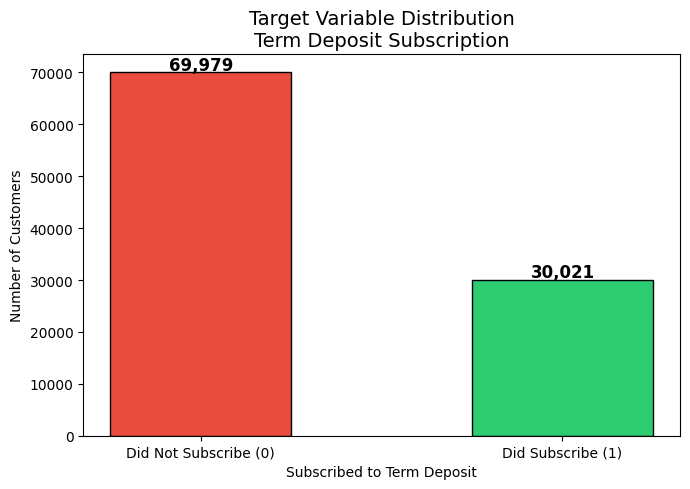

Chart saved as target_distribution.png


In [7]:
# ~~~ Target Variable Distribution ~~~
print("=" * 50)
print("TARGET VARIABLE — TermDepositSubscribed")
print("=" * 50)

counts = df['TermDepositSubscribed'].value_counts()
percentages = df['TermDepositSubscribed'].value_counts(normalize=True) * 100

print(f"Class 0 (Did NOT subscribe): {counts[0]} ({percentages[0]:.1f}%)")
print(f"Class 1 (DID subscribe):     {counts[1]} ({percentages[1]:.1f}%)")

# Plot
plt.figure(figsize=(7, 5))
bars = plt.bar(['Did Not Subscribe (0)', 'Did Subscribe (1)'],
               [counts[0], counts[1]],
               color=['#e74c3c', '#2ecc71'], edgecolor='black', width=0.5)

# Add count labels on bars
for bar, count in zip(bars, [counts[0], counts[1]]):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{count:,}', ha='center', fontsize=12, fontweight='bold')

plt.title('Target Variable Distribution\nTerm Deposit Subscription', fontsize=14)
plt.ylabel('Number of Customers')
plt.xlabel('Subscribed to Term Deposit')
plt.tight_layout()
plt.savefig('target_distribution.png', dpi=150)
plt.show()
print("Chart saved as target_distribution.png")

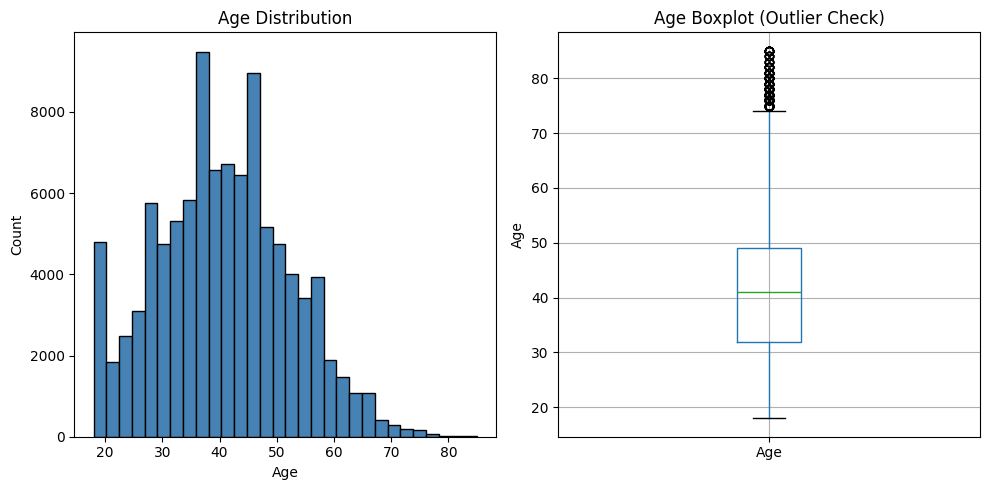

Chart saved


In [8]:
# ~~~ Age Distribution ~~~
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
df.boxplot(column='Age', vert=True)
plt.title('Age Boxplot (Outlier Check)')
plt.ylabel('Age')

plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150)
plt.show()
print("Chart saved")

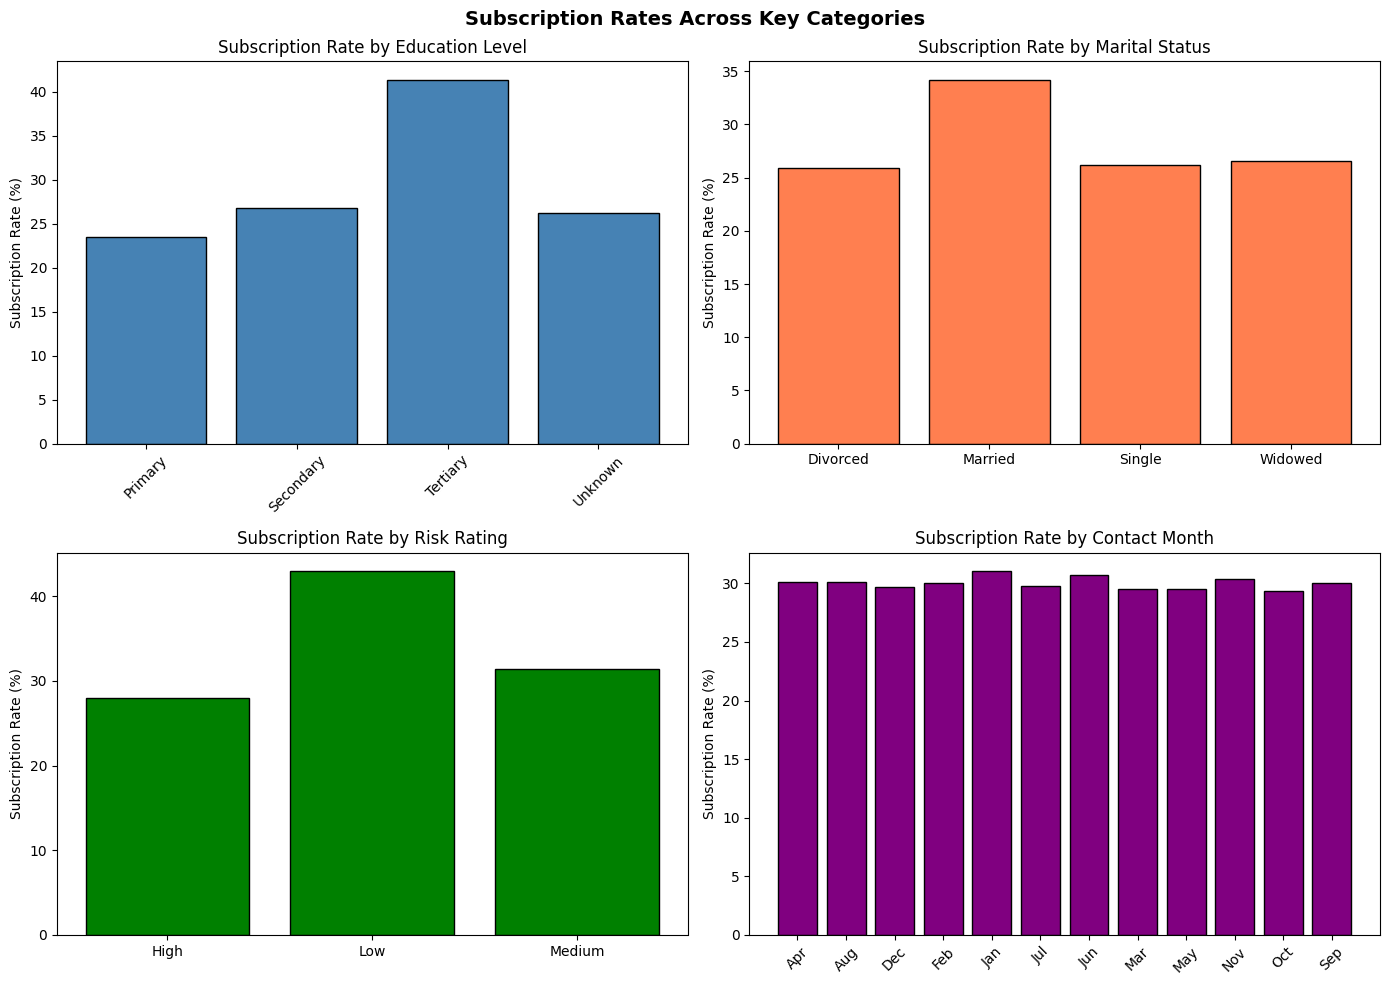

Chart saved


In [9]:
# ~~~ Subscription Rate by Categories ~~~
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# By Education Level
edu_sub = df.groupby('EducationLevel')['TermDepositSubscribed'].mean() * 100
axes[0,0].bar(edu_sub.index, edu_sub.values, color='steelblue', edgecolor='black')
axes[0,0].set_title('Subscription Rate by Education Level')
axes[0,0].set_ylabel('Subscription Rate (%)')
axes[0,0].tick_params(axis='x', rotation=45)

# By Marital Status
mar_sub = df.groupby('MaritalStatus')['TermDepositSubscribed'].mean() * 100
axes[0,1].bar(mar_sub.index, mar_sub.values, color='coral', edgecolor='black')
axes[0,1].set_title('Subscription Rate by Marital Status')
axes[0,1].set_ylabel('Subscription Rate (%)')

# By Risk Rating
risk_sub = df.groupby('RiskRating')['TermDepositSubscribed'].mean() * 100
axes[1,0].bar(risk_sub.index, risk_sub.values, color='green', edgecolor='black')
axes[1,0].set_title('Subscription Rate by Risk Rating')
axes[1,0].set_ylabel('Subscription Rate (%)')

# By Last Contact Month
month_sub = df.groupby('LastContactMonth')['TermDepositSubscribed'].mean() * 100
axes[1,1].bar(month_sub.index, month_sub.values, color='purple', edgecolor='black')
axes[1,1].set_title('Subscription Rate by Contact Month')
axes[1,1].set_ylabel('Subscription Rate (%)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Subscription Rates Across Key Categories', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_subscription_rates.png', dpi=150)
plt.show()
print("Chart saved")

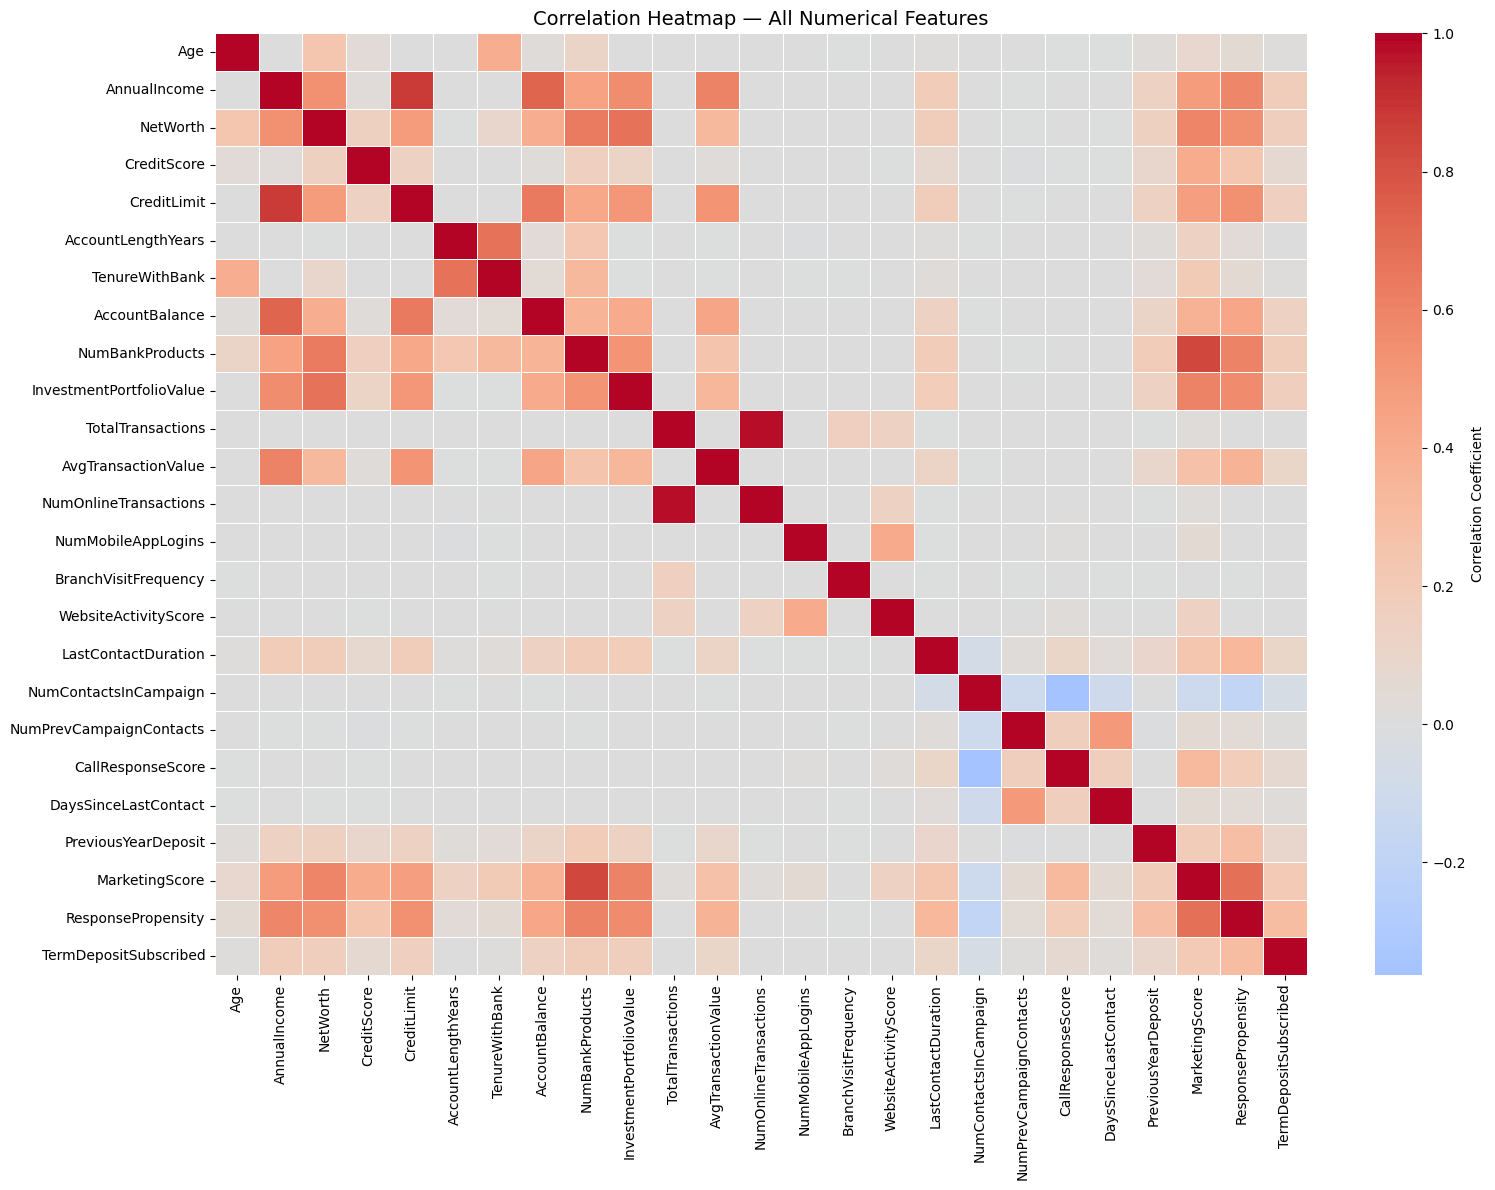

Heatmap saved


In [10]:
# ~~~ Correlation Heatmap ~~~
plt.figure(figsize=(16, 12))

# Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove ClientID as it is not meaningful
if 'ClientID' in numerical_cols:
    numerical_cols.remove('ClientID')

corr_matrix = df[numerical_cols].corr()

sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            center=0,
            linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})

plt.title('Correlation Heatmap — All Numerical Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved")

TOP CORRELATIONS WITH TermDepositSubscribed

Top 10 most correlated features:
ResponsePropensity          0.3020
MarketingScore              0.2058
NumBankProducts             0.1792
AnnualIncome                0.1776
InvestmentPortfolioValue    0.1727
NetWorth                    0.1657
CreditLimit                 0.1618
AccountBalance              0.1329
AvgTransactionValue         0.1107
LastContactDuration         0.1041
Name: TermDepositSubscribed, dtype: float64


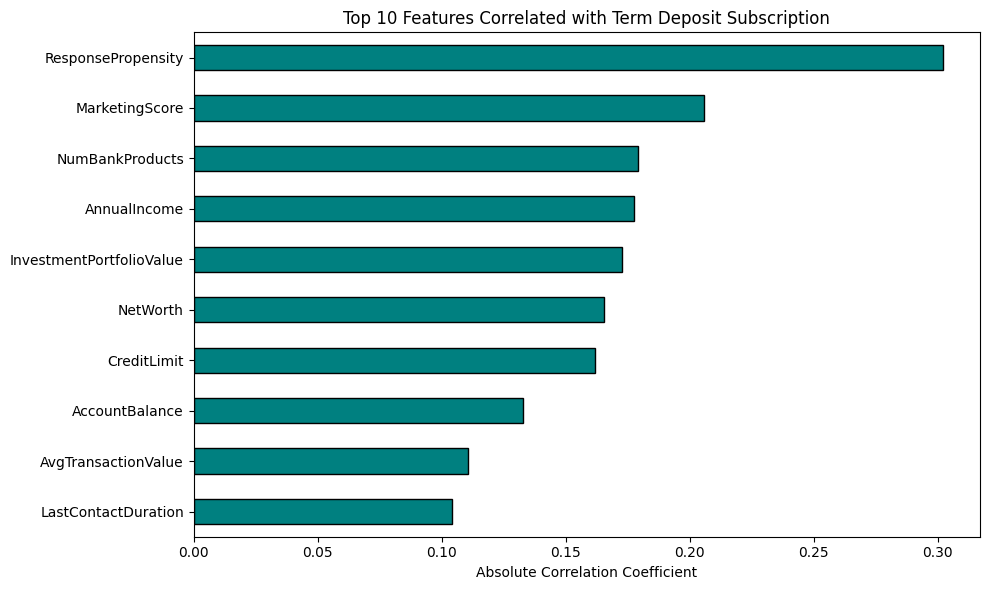

Chart saved


In [11]:
# ~~~ Top Features Correlated with Target ~~~
print("=" * 50)
print("TOP CORRELATIONS WITH TermDepositSubscribed")
print("=" * 50)

target_corr = corr_matrix['TermDepositSubscribed'].drop('TermDepositSubscribed')
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

print("\nTop 10 most correlated features:")
print(target_corr_sorted.head(10).round(4))

# Plot
plt.figure(figsize=(10, 6))
target_corr_sorted.head(10).plot(kind='barh', color='teal', edgecolor='black')
plt.title('Top 10 Features Correlated with Term Deposit Subscription')
plt.xlabel('Absolute Correlation Coefficient')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('top_correlations.png', dpi=150)
plt.show()
print("Chart saved")

In [12]:
# Data Cleaning

# Reload completely fresh from the original file
df = pd.read_csv('Bank_Marketing_Dataset.csv')
df_clean = df.copy()

print(f"Dataset reloaded fresh from CSV")
print(f"Original df shape:    {df.shape}")
print(f"Clean copy shape:     {df_clean.shape}")
print(f"Rows confirmed:       {df_clean.shape[0]:,}")

# Verify target variable is intact
print(f"\nTarget variable check:")
print(df['TermDepositSubscribed'].value_counts())

Dataset reloaded fresh from CSV
Original df shape:    (100000, 45)
Clean copy shape:     (100000, 45)
Rows confirmed:       100,000

Target variable check:
TermDepositSubscribed
0    69979
1    30021
Name: count, dtype: int64


In [13]:
# Drop ClientID
df_clean = df_clean.drop(columns=['ClientID'])
print(f" ClientID dropped. Shape: {df_clean.shape}")



 ClientID dropped. Shape: (100000, 44)


In [14]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# Replace 'nan' strings with actual NaN, then fill them
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
import numpy as np

# Check all object columns for 'nan' strings
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

print("Checking for 'nan' string values:")
for col in categorical_cols:
    nan_count = (df_clean[col].astype(str) == 'nan').sum()
    if nan_count > 0:
        print(f" {col}: {nan_count} 'nan' values found")

# Replace string 'nan' with actual NaN
df_clean[categorical_cols] = df_clean[categorical_cols].replace('nan', np.nan)

# Fill NaN in categorical columns with the most frequent value (mode)
print("\nFilling missing values with most frequent value:")
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f" {col}: filled with '{mode_val}'")

# Verify no more missing values in categorical columns
remaining = df_clean[categorical_cols].isnull().sum().sum()
print(f"\nRemaining missing values in categorical columns: {remaining}")
print("All categorical NaN values handled!")

Checking for 'nan' string values:

Filling missing values with most frequent value:

Remaining missing values in categorical columns: 0
All categorical NaN values handled!


In [15]:
# Encode binary Yes or No columns to 1 or 0
binary_cols = ['HasCreditCard', 'HasMortgage', 'HasPersonalLoan',
               'HasLifeInsurance', 'HasMutualFunds']

for col in binary_cols:
    df_clean[col] = df_clean[col].map({'Yes': 1, 'No': 0})
    print(f" {col}: Yes→1, No→0")

print(f"\nShape: {df_clean.shape}")

 HasCreditCard: Yes→1, No→0
 HasMortgage: Yes→1, No→0
 HasPersonalLoan: Yes→1, No→0
 HasLifeInsurance: Yes→1, No→0
 HasMutualFunds: Yes→1, No→0

Shape: (100000, 44)


In [16]:
# Ordinal encoding
risk_order = {'Low': 0, 'Medium': 1, 'High': 2}
df_clean['RiskRating'] = df_clean['RiskRating'].map(risk_order)

edu_order = {'Primary': 0, 'Secondary': 1, 'Tertiary': 2, 'Unknown': 3}
df_clean['EducationLevel'] = df_clean['EducationLevel'].map(edu_order)

salary_order = {'Low': 0, 'Mid': 1, 'High': 2, 'UpperMid': 3}
df_clean['SalaryCategory'] = df_clean['SalaryCategory'].map(salary_order)

print("Ordinal encoding complete")
print(df_clean[['RiskRating', 'EducationLevel', 'SalaryCategory']].head(3))
print(f"Shape: {df_clean.shape}")

Ordinal encoding complete
   RiskRating  EducationLevel  SalaryCategory
0           2               1               1
1           1               1               0
2           2               1               1
Shape: (100000, 44)


In [17]:
# Fix any remaining NaN from ordinal encoding
ordinal_cols = ['RiskRating', 'EducationLevel', 'SalaryCategory']
for col in ordinal_cols:
    if df_clean[col].isnull().sum() > 0:
        fill_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(fill_val)
        print(f"{col}: {df_clean[col].isnull().sum()} remaining NaN filled")

print(f"\nTotal missing values after ordinal fix: {df_clean.isnull().sum().sum()}")


Total missing values after ordinal fix: 0


In [18]:
# One-Hot Encode nominal columns
nominal_cols = ['Gender', 'MaritalStatus', 'EmploymentStatus', 'JobTitle',
                'Region', 'CustomerSegment', 'ChannelPreference',
                'LastContactChannel', 'LastContactMonth', 'LastContactDay',
                'PrevCampaignOutcome']

print(f"Shape before one-hot encoding: {df_clean.shape}")

df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)

# FIX: Convert boolean columns to integers (0/1)
bool_cols = df_clean.select_dtypes(include=['bool']).columns.tolist()
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f"Shape after one-hot encoding:  {df_clean.shape}")
print(f"Boolean columns converted to int: {len(bool_cols)}")
print("One-hot encoding complete — no boolean columns remain")
print(f"Data types now: {df_clean.dtypes.value_counts().to_dict()}")

Shape before one-hot encoding: (100000, 44)
Shape after one-hot encoding:  (100000, 78)
Boolean columns converted to int: 45
One-hot encoding complete — no boolean columns remain
Data types now: {dtype('int64'): 68, dtype('float64'): 10}


In [19]:
# StandardScaler on numerical columns
from sklearn.preprocessing import StandardScaler

cols_to_scale = ['Age', 'AnnualIncome', 'NetWorth', 'CreditScore', 'CreditLimit',
                 'AccountLengthYears', 'TenureWithBank', 'AccountBalance',
                 'NumBankProducts', 'InvestmentPortfolioValue', 'TotalTransactions',
                 'AvgTransactionValue', 'NumOnlineTransactions', 'NumMobileAppLogins',
                 'BranchVisitFrequency', 'WebsiteActivityScore', 'LastContactDuration',
                 'NumContactsInCampaign', 'NumPrevCampaignContacts', 'CallResponseScore',
                 'DaysSinceLastContact', 'PreviousYearDeposit', 'MarketingScore',
                 'ResponsePropensity']

scaler = StandardScaler()
df_clean[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

print("StandardScaler applied")
print(f"Age mean after scaling: {df_clean['Age'].mean():.4f} (should be ~0)")
print(f"Age std after scaling:  {df_clean['Age'].std():.4f} (should be ~1)")

StandardScaler applied
Age mean after scaling: 0.0000 (should be ~0)
Age std after scaling:  1.0000 (should be ~1)


In [20]:
# FINAL VERIFICATION

print("=" * 55)
print("FINAL CLEANED DATASET — VERIFICATION")
print("=" * 55)
print(f"Shape:              {df_clean.shape}")
print(f"Total rows:         {df_clean.shape[0]:,}")
print(f"Missing values:     {df_clean.isnull().sum().sum()}")
print(f"Data types:         {df_clean.dtypes.value_counts().to_dict()}")

print(f"\nTarget variable check:")
print(df_clean['TermDepositSubscribed'].value_counts())

print(f"\n All checks passed — ready for Feature Engineering!")

FINAL CLEANED DATASET — VERIFICATION
Shape:              (100000, 78)
Total rows:         100,000
Missing values:     0
Data types:         {dtype('int64'): 54, dtype('float64'): 24}

Target variable check:
TermDepositSubscribed
0    69979
1    30021
Name: count, dtype: int64

 All checks passed — ready for Feature Engineering!


In [21]:
print("=" * 55)
print("DATA CLEANING — BEFORE vs AFTER SUMMARY (CORRECTED)")
print("=" * 55)
print(f"{'Step':<35} {'Before':<15} {'After'}")
print("-" * 55)
print(f"{'Total rows':<35} {'100,000':<15} {df_clean.shape[0]:,}")
print(f"{'Number of columns':<35} {'45':<15} {df_clean.shape[1]}")
print(f"{'Missing values':<35} {'0':<15} {df_clean.isnull().sum().sum()}")
print(f"{'NaN string values':<35} {'Present':<15} {'Removed'}")
print(f"{'Categorical columns':<35} {'19':<15} {'0'}")
print(f"{'Feature scaling':<35} {'No':<15} {'Yes (StandardScaler)'}")
print(f"{'ClientID removed':<35} {'No':<15} {'Yes'}")
print(f"{'Boolean columns':<35} {'Created':<15} {'Converted to int'}")
print("-" * 55)
print("Data Cleaning Complete!")

DATA CLEANING — BEFORE vs AFTER SUMMARY (CORRECTED)
Step                                Before          After
-------------------------------------------------------
Total rows                          100,000         100,000
Number of columns                   45              78
Missing values                      0               0
NaN string values                   Present         Removed
Categorical columns                 19              0
Feature scaling                     No              Yes (StandardScaler)
ClientID removed                    No              Yes
Boolean columns                     Created         Converted to int
-------------------------------------------------------
Data Cleaning Complete!


In [22]:
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
# FEATURE ENGINEERING
# ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

# Separate features (X) and target (y)
X = df_clean.drop(columns=['TermDepositSubscribed'])
y = df_clean['TermDepositSubscribed']

print(f"Features matrix X shape: {X.shape}")
print(f"Target vector y shape:   {y.shape}")
print(f"\nTarget distribution:")
print(f"  Class 0 (No):  {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")
print(f"  Class 1 (Yes): {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)")
print("\n X and y created successfully!")

Features matrix X shape: (100000, 77)
Target vector y shape:   (100000,)

Target distribution:
  Class 0 (No):  69,979 (70.0%)
  Class 1 (Yes): 30,021 (30.0%)

 X and y created successfully!


In [23]:
# --- Feature Importance using Random Forest ---
from sklearn.ensemble import RandomForestClassifier

print("Running feature importance analysis...")
print("(This may take 30-60 seconds on 100,000 rows)")

# Quick Random Forest just for feature importance
rf_temp = RandomForestClassifier(n_estimators=50,
                                  max_depth=10,
                                  random_state=42,
                                  n_jobs=-1)
rf_temp.fit(X, y)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nFeature importance calculated!")
print(f"\nTop 15 most important features:")
print(feature_importance.head(15).round(4).to_string(index=False))

Running feature importance analysis...
(This may take 30-60 seconds on 100,000 rows)

Feature importance calculated!

Top 15 most important features:
                 Feature  Importance
      ResponsePropensity      0.1937
InvestmentPortfolioValue      0.0788
          MarketingScore      0.0691
            AnnualIncome      0.0573
         NumBankProducts      0.0558
                NetWorth      0.0467
     LastContactDuration      0.0422
          SalaryCategory      0.0385
          EducationLevel      0.0358
             CreditLimit      0.0288
          AccountBalance      0.0254
       CallResponseScore      0.0238
             CreditScore      0.0230
    WebsiteActivityScore      0.0183
   MaritalStatus_Married      0.0183


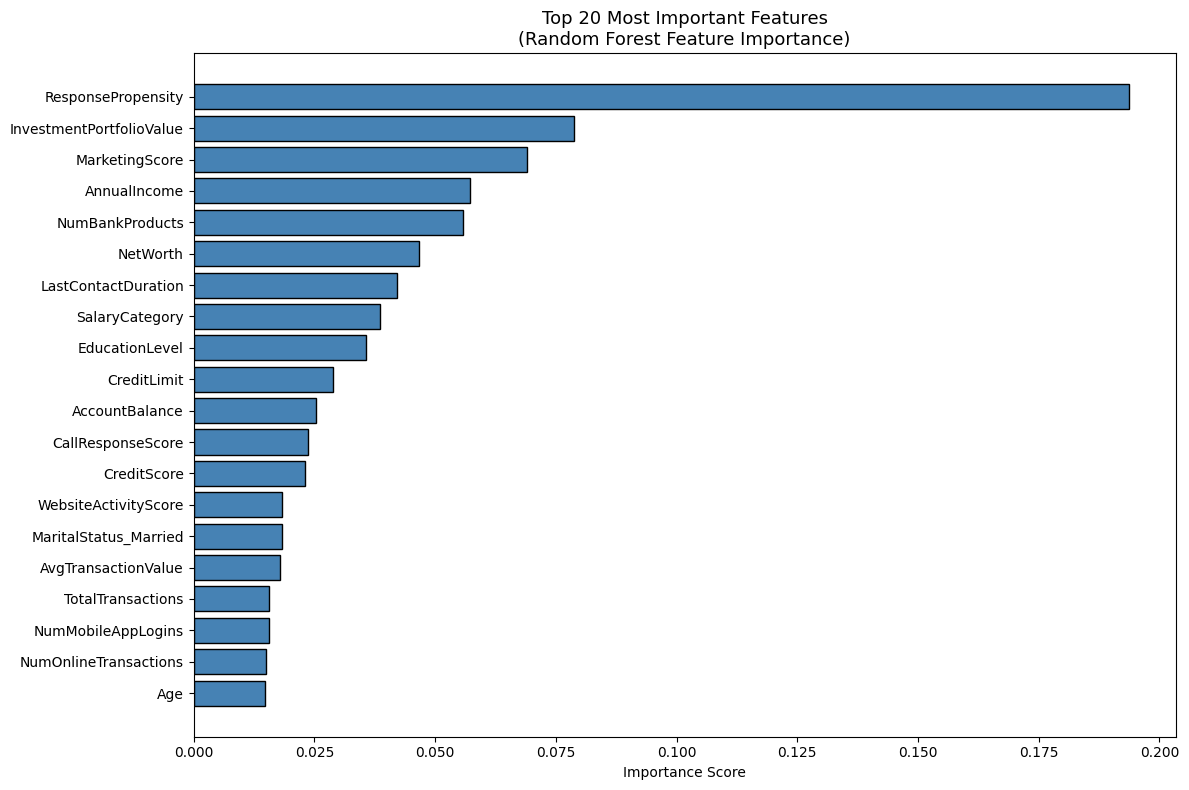

Feature importance chart saved


In [24]:
# --- Plot Feature Importances ---
plt.figure(figsize=(12, 8))
top20 = feature_importance.head(20)

plt.barh(top20['Feature'], top20['Importance'],
         color='steelblue', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Top 20 Most Important Features\n(Random Forest Feature Importance)',
          fontsize=13)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved")

In [25]:
# --- Select Top Features for Modelling ---
# Keep features with importance above threshold
threshold = 0.01  # Keep features contributing more than 1%

selected_features = feature_importance[
    feature_importance['Importance'] >= threshold
]['Feature'].tolist()

print(f"Total features available:  {X.shape[1]}")
print(f"Features above threshold:  {len(selected_features)}")
print(f"Features removed:          {X.shape[1] - len(selected_features)}")
print(f"\nSelected features ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    imp = feature_importance[feature_importance['Feature']==feat]['Importance'].values[0]
    print(f"  {i:2}. {feat:<40} {imp:.4f}")

Total features available:  77
Features above threshold:  23
Features removed:          54

Selected features (23):
   1. ResponsePropensity                       0.1937
   2. InvestmentPortfolioValue                 0.0788
   3. MarketingScore                           0.0691
   4. AnnualIncome                             0.0573
   5. NumBankProducts                          0.0558
   6. NetWorth                                 0.0467
   7. LastContactDuration                      0.0422
   8. SalaryCategory                           0.0385
   9. EducationLevel                           0.0358
  10. CreditLimit                              0.0288
  11. AccountBalance                           0.0254
  12. CallResponseScore                        0.0238
  13. CreditScore                              0.0230
  14. WebsiteActivityScore                     0.0183
  15. MaritalStatus_Married                    0.0183
  16. AvgTransactionValue                      0.0179
  17. TotalTransactio

In [26]:
# --- Create New Features (Feature Engineering) ---
# We create new meaningful features from existing ones

# Work on a fresh copy before selection
df_engineered = df_clean.copy()

# Feature 1: Wealth Score (combination of financial features)
df_engineered['WealthScore'] = (
    df_clean['AnnualIncome'] +
    df_clean['NetWorth'] +
    df_clean['AccountBalance']
) / 3

# Feature 2: Digital Engagement Score
df_engineered['DigitalEngagement'] = (
    df_clean['NumOnlineTransactions'] +
    df_clean['NumMobileAppLogins'] +
    df_clean['WebsiteActivityScore']
) / 3

# Feature 3: Campaign Intensity
df_engineered['CampaignIntensity'] = (
    df_clean['NumContactsInCampaign'] +
    df_clean['NumPrevCampaignContacts']
)

# Feature 4: Product Engagement
df_engineered['ProductEngagement'] = (
    df_clean['NumBankProducts'] *
    df_clean['TotalTransactions']
)

print("New engineered features created:")
print("  1. WealthScore          — combined financial strength indicator")
print("  2. DigitalEngagement    — combined digital activity indicator")
print("  3. CampaignIntensity    — total campaign contact pressure")
print("  4. ProductEngagement    — interaction between products and activity")

new_feats = ['WealthScore', 'DigitalEngagement',
             'CampaignIntensity', 'ProductEngagement']
print(f"\nSample values:")
print(df_engineered[new_feats].head(3).round(4))

New engineered features created:
  1. WealthScore          — combined financial strength indicator
  2. DigitalEngagement    — combined digital activity indicator
  3. CampaignIntensity    — total campaign contact pressure
  4. ProductEngagement    — interaction between products and activity

Sample values:
   WealthScore  DigitalEngagement  CampaignIntensity  ProductEngagement
0      -0.1198            -0.3831             1.2904            -0.3873
1      -0.2678            -0.3000            -2.0980            -0.1167
2      -0.5230            -0.3016             4.0319            -0.4790


In [27]:
# --- Check if new features correlate with target ---
print("Correlation of new features with TermDepositSubscribed:")
print("=" * 55)

for feat in new_feats:
    corr = df_engineered[feat].corr(df_clean['TermDepositSubscribed'])
    print(f"  {feat:<25} r = {corr:.4f}")

print("\nFor reference, original top correlations were:")
print("  ResponsePropensity        r = 0.3020")
print("  MarketingScore            r = 0.2058")
print("  NumBankProducts           r = 0.1792")

Correlation of new features with TermDepositSubscribed:
  WealthScore               r = 0.1894
  DigitalEngagement         r = 0.0060
  CampaignIntensity         r = -0.0311
  ProductEngagement         r = 0.0066

For reference, original top correlations were:
  ResponsePropensity        r = 0.3020
  MarketingScore            r = 0.2058
  NumBankProducts           r = 0.1792


In [28]:
# --- Prepare Final X and y for Modelling ---

# Add engineered features to X
X_final = X.copy()
X_final['WealthScore'] = df_engineered['WealthScore']
X_final['DigitalEngagement'] = df_engineered['DigitalEngagement']
X_final['CampaignIntensity'] = df_engineered['CampaignIntensity']
X_final['ProductEngagement'] = df_engineered['ProductEngagement']

# Apply scaling to new features too
new_feat_cols = ['WealthScore', 'DigitalEngagement',
                 'CampaignIntensity', 'ProductEngagement']
X_final[new_feat_cols] = scaler.fit_transform(X_final[new_feat_cols])

print(f"Final feature matrix shape: {X_final.shape}")
print(f"Target vector shape:        {y.shape}")
print(f"\nTotal features for modelling: {X_final.shape[1]}")
print("  - Original features: 77")
print(f"  - Engineered features: 4")
print(f"  - Total: {X_final.shape[1]}")
print("\nFinal feature set ready for model training!")

Final feature matrix shape: (100000, 81)
Target vector shape:        (100000,)

Total features for modelling: 81
  - Original features: 77
  - Engineered features: 4
  - Total: 81

Final feature set ready for model training!


In [29]:
# --- Train-Test Split ---
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.2,      # 80% training, 20% testing
    random_state=42,    # ensures reproducibility
    stratify=y          # keeps class ratio same in both splits
)

print("=" * 50)
print("TRAIN-TEST SPLIT SUMMARY")
print("=" * 50)
print(f"Total samples:       {len(X_final):,}")
print(f"Training samples:    {len(X_train):,} (80%)")
print(f"Testing samples:     {len(X_test):,}  (20%)")
print(f"\nTraining target distribution:")
print(f"  Class 0: {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"\nTesting target distribution:")
print(f"  Class 0: {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")
print(f"  Class 1: {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")
print("\nTrain-test split complete — ready for modelling!")

TRAIN-TEST SPLIT SUMMARY
Total samples:       100,000
Training samples:    80,000 (80%)
Testing samples:     20,000  (20%)

Training target distribution:
  Class 0: 55,983 (70.0%)
  Class 1: 24,017 (30.0%)

Testing target distribution:
  Class 0: 13,996 (70.0%)
  Class 1: 6,004 (30.0%)

Train-test split complete — ready for modelling!


In [30]:
# Train Logistic Regression
# ============================================================
# MODEL IMPLEMENTATION
# ============================================================

# --- MODEL 1: Logistic Regression (Baseline) ---
print("=" * 55)
print("MODEL 1 — LOGISTIC REGRESSION (BASELINE)")
print("=" * 55)

from sklearn.linear_model import LogisticRegression
import time

# Train the model
print("\nTraining Logistic Regression...")
start_time = time.time()

model1_lr = LogisticRegression(
    max_iter=1000,      # allow enough iterations to converge
    random_state=42,
    solver='lbfgs'
)
model1_lr.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Training complete in {train_time:.2f} seconds")

# Predictions
y_pred_lr = model1_lr.predict(X_test)
y_prob_lr = model1_lr.predict_proba(X_test)[:, 1]

print(f"\nPredictions made on {len(y_test):,} test samples")
print(f"Sample predictions (first 10): {y_pred_lr[:10].tolist()}")
print(f"Actual values      (first 10): {y_test[:10].tolist()}")

MODEL 1 — LOGISTIC REGRESSION (BASELINE)

Training Logistic Regression...
Training complete in 3.24 seconds

Predictions made on 20,000 test samples
Sample predictions (first 10): [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
Actual values      (first 10): [1, 0, 1, 1, 0, 0, 0, 1, 0, 0]


In [31]:
# Evaluate Logistic Regression
# --- Evaluate Model 1 ---
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report)

acc_lr    = accuracy_score(y_test, y_pred_lr)
prec_lr   = precision_score(y_test, y_pred_lr)
rec_lr    = recall_score(y_test, y_pred_lr)
f1_lr     = f1_score(y_test, y_pred_lr)
roc_lr    = roc_auc_score(y_test, y_prob_lr)

print("=" * 55)
print("MODEL 1 — LOGISTIC REGRESSION RESULTS")
print("=" * 55)
print(f"  Accuracy:   {acc_lr:.4f}  ({acc_lr*100:.2f}%)")
print(f"  Precision:  {prec_lr:.4f}")
print(f"  Recall:     {rec_lr:.4f}")
print(f"  F1-Score:   {f1_lr:.4f}")
print(f"  ROC-AUC:    {roc_lr:.4f}")

print("\nFull Classification Report:")
print(classification_report(y_test, y_pred_lr,
      target_names=['No Subscription', 'Subscription']))

MODEL 1 — LOGISTIC REGRESSION RESULTS
  Accuracy:   0.7097  (70.97%)
  Precision:  0.5421
  Recall:     0.2110
  F1-Score:   0.3038
  ROC-AUC:    0.6814

Full Classification Report:
                 precision    recall  f1-score   support

No Subscription       0.73      0.92      0.82     13996
   Subscription       0.54      0.21      0.30      6004

       accuracy                           0.71     20000
      macro avg       0.64      0.57      0.56     20000
   weighted avg       0.67      0.71      0.66     20000



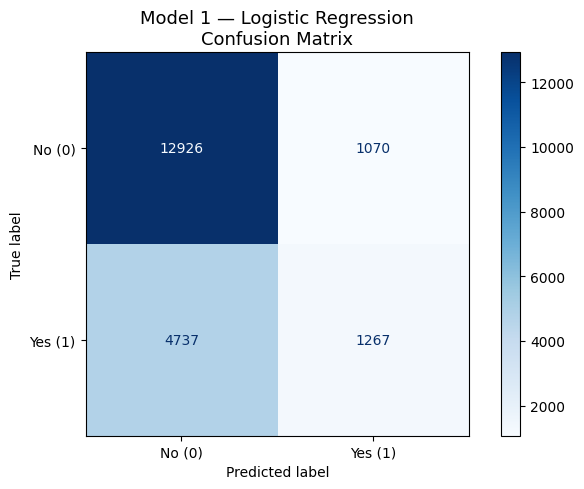


Confusion Matrix Breakdown:
  True Negatives  (correctly predicted No):  12,926
  False Positives (predicted Yes, was No):   1,070
  False Negatives (predicted No, was Yes):   4,737
  True Positives  (correctly predicted Yes): 1,267
Confusion matrix saved


In [32]:
# Confusion Matrix for Model 1
# --- Confusion Matrix Model 1 ---
fig, ax = plt.subplots(figsize=(7, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['No (0)', 'Yes (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Model 1 — Logistic Regression\nConfusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=150)
plt.show()

# Interpret the matrix
tn, fp, fn, tp = cm_lr.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (correctly predicted No):  {tn:,}")
print(f"  False Positives (predicted Yes, was No):   {fp:,}")
print(f"  False Negatives (predicted No, was Yes):   {fn:,}")
print(f"  True Positives  (correctly predicted Yes): {tp:,}")
print("Confusion matrix saved")

In [33]:
# Train Decision Tree (Initial — Deliberately Overfitted)
# ============================================================
# MODEL 2 — DECISION TREE (with debugging evidence)
# ============================================================
print("=" * 55)
print("MODEL 2 — DECISION TREE")
print("=" * 55)

from sklearn.tree import DecisionTreeClassifier

# --- ATTEMPT 1: No depth limit (will overfit — debugging evidence) ---
print("\n[Attempt 1] Training with no max_depth (overfit expected)...")

model2_dt_v1 = DecisionTreeClassifier(random_state=42)
model2_dt_v1.fit(X_train, y_train)

train_score_v1 = model2_dt_v1.score(X_train, y_train)
test_score_v1  = model2_dt_v1.score(X_test, y_test)

print(f"  Training accuracy: {train_score_v1:.4f} ({train_score_v1*100:.2f}%)")
print(f"  Testing accuracy:  {test_score_v1:.4f}  ({test_score_v1*100:.2f}%)")
print(f"  Tree depth: {model2_dt_v1.get_depth()}")
print(f"\nLarge gap between train ({train_score_v1*100:.1f}%) and test ({test_score_v1*100:.1f}%) = OVERFITTING")
print("  This is a key debugging observation — we need to tune max_depth")

MODEL 2 — DECISION TREE

[Attempt 1] Training with no max_depth (overfit expected)...
  Training accuracy: 1.0000 (100.00%)
  Testing accuracy:  0.6116  (61.16%)
  Tree depth: 53

Large gap between train (100.0%) and test (61.2%) = OVERFITTING
  This is a key debugging observation — we need to tune max_depth


In [34]:
#  Fix Decision Tree (Tuned Version)
# --- ATTEMPT 2: Tuned with max_depth (fixing overfitting) ---
print("\n[Attempt 2] Tuning with max_depth=10...")

model2_dt_v2 = DecisionTreeClassifier(
    max_depth=10,       # limit depth to prevent overfitting
    min_samples_split=50,
    min_samples_leaf=20,
    random_state=42
)
model2_dt_v2.fit(X_train, y_train)

train_score_v2 = model2_dt_v2.score(X_train, y_train)
test_score_v2  = model2_dt_v2.score(X_test, y_test)

print(f"  Training accuracy: {train_score_v2:.4f} ({train_score_v2*100:.2f}%)")
print(f"  Testing accuracy:  {test_score_v2:.4f}  ({test_score_v2*100:.2f}%)")
print(f"  Tree depth: {model2_dt_v2.get_depth()}")
print(f"\nGap reduced — overfitting controlled by max_depth=10")

# Final predictions
y_pred_dt  = model2_dt_v2.predict(X_test)
y_prob_dt  = model2_dt_v2.predict_proba(X_test)[:, 1]


[Attempt 2] Tuning with max_depth=10...
  Training accuracy: 0.7268 (72.68%)
  Testing accuracy:  0.7008  (70.08%)
  Tree depth: 10

Gap reduced — overfitting controlled by max_depth=10


MODEL 2 — DECISION TREE RESULTS (Tuned)
  Accuracy:   0.7008  (70.08%)
  Precision:  0.5046
  Recall:     0.1822
  F1-Score:   0.2677
  ROC-AUC:    0.6578


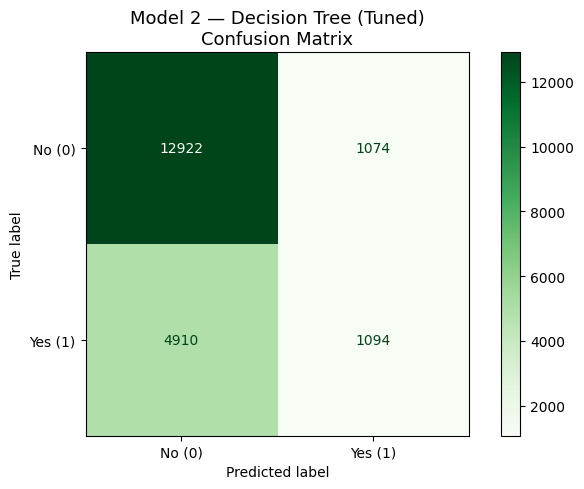

Confusion matrix saved


In [35]:
# Evaluate Decision Tree
# --- Evaluate Model 2 ---
acc_dt    = accuracy_score(y_test, y_pred_dt)
prec_dt   = precision_score(y_test, y_pred_dt)
rec_dt    = recall_score(y_test, y_pred_dt)
f1_dt     = f1_score(y_test, y_pred_dt)
roc_dt    = roc_auc_score(y_test, y_prob_dt)

print("=" * 55)
print("MODEL 2 — DECISION TREE RESULTS (Tuned)")
print("=" * 55)
print(f"  Accuracy:   {acc_dt:.4f}  ({acc_dt*100:.2f}%)")
print(f"  Precision:  {prec_dt:.4f}")
print(f"  Recall:     {rec_dt:.4f}")
print(f"  F1-Score:   {f1_dt:.4f}")
print(f"  ROC-AUC:    {roc_dt:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                               display_labels=['No (0)', 'Yes (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Greens')
ax.set_title('Model 2 — Decision Tree (Tuned)\nConfusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('cm_decision_tree.png', dpi=150)
plt.show()
print("Confusion matrix saved")

In [36]:
#  Train Random Forest (Initial Version)
# ============================================================
# MODEL 3 — RANDOM FOREST (Advanced)
# ============================================================
print("=" * 55)
print("MODEL 3 — RANDOM FOREST (ADVANCED)")
print("=" * 55)

from sklearn.ensemble import RandomForestClassifier

# --- ATTEMPT 1: Default parameters ---
print("\n[Attempt 1] Training with default parameters...")
print("(This may take 1-2 minutes on 100,000 rows)")

model3_rf_v1 = RandomForestClassifier(
    n_estimators=50,    # start with fewer trees
    random_state=42,
    n_jobs=-1
)
model3_rf_v1.fit(X_train, y_train)

train_score_rf1 = model3_rf_v1.score(X_train, y_train)
test_score_rf1  = model3_rf_v1.score(X_test, y_test)

print(f"  Training accuracy: {train_score_rf1:.4f}")
print(f"  Testing accuracy:  {test_score_rf1:.4f}")
print(f"\nInitial result noted — now tuning for better performance")

MODEL 3 — RANDOM FOREST (ADVANCED)

[Attempt 1] Training with default parameters...
(This may take 1-2 minutes on 100,000 rows)
  Training accuracy: 0.9998
  Testing accuracy:  0.7043

Initial result noted — now tuning for better performance


In [37]:
# Tuned Random Forest (Best Version)
# --- ATTEMPT 2: Tuned Random Forest ---
print("\n[Attempt 2] Training tuned Random Forest...")
print("(This may take 2-3 minutes)")

model3_rf = RandomForestClassifier(
    n_estimators=100,       # more trees = better performance
    max_depth=15,           # controlled depth
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',    # use square root of features at each split
    random_state=42,
    n_jobs=-1               # use all CPU cores
)
model3_rf.fit(X_train, y_train)

train_score_rf = model3_rf.score(X_train, y_train)
test_score_rf  = model3_rf.score(X_test, y_test)

print(f"  Training accuracy: {train_score_rf:.4f}")
print(f"  Testing accuracy:  {test_score_rf:.4f}")

# Predictions
y_pred_rf = model3_rf.predict(X_test)
y_prob_rf = model3_rf.predict_proba(X_test)[:, 1]
print("\nTuned Random Forest training complete!")


[Attempt 2] Training tuned Random Forest...
(This may take 2-3 minutes)
  Training accuracy: 0.7806
  Testing accuracy:  0.7088

Tuned Random Forest training complete!


MODEL 3 — RANDOM FOREST RESULTS (Tuned)
  Accuracy:   0.7088  (70.88%)
  Precision:  0.5481
  Recall:     0.1707
  F1-Score:   0.2604
  ROC-AUC:    0.6781


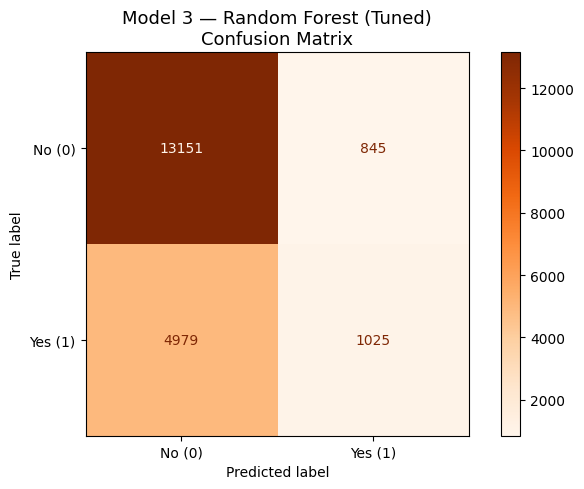

Confusion matrix saved


In [38]:
# Evaluate Random Forest
# --- Evaluate Model 3 ---
acc_rf    = accuracy_score(y_test, y_pred_rf)
prec_rf   = precision_score(y_test, y_pred_rf)
rec_rf    = recall_score(y_test, y_pred_rf)
f1_rf     = f1_score(y_test, y_pred_rf)
roc_rf    = roc_auc_score(y_test, y_prob_rf)

print("=" * 55)
print("MODEL 3 — RANDOM FOREST RESULTS (Tuned)")
print("=" * 55)
print(f"  Accuracy:   {acc_rf:.4f}  ({acc_rf*100:.2f}%)")
print(f"  Precision:  {prec_rf:.4f}")
print(f"  Recall:     {rec_rf:.4f}")
print(f"  F1-Score:   {f1_rf:.4f}")
print(f"  ROC-AUC:    {roc_rf:.4f}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf,
                               display_labels=['No (0)', 'Yes (1)'])
disp.plot(ax=ax, colorbar=True, cmap='Oranges')
ax.set_title('Model 3 — Random Forest (Tuned)\nConfusion Matrix', fontsize=13)
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=150)
plt.show()
print("Confusion matrix saved")

In [39]:
# Debugging Evidence Summary
# ============================================================
# SECTION 6 — DEBUGGING EVIDENCE SUMMARY
# ============================================================

print("=" * 60)
print("DEBUGGING EVIDENCE — ALL MODELS")
print("=" * 60)

print("""
MODEL 1 — LOGISTIC REGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Issue:   Low recall (0.2110) — model misses 79% of actual subscribers
Cause:   Class imbalance (70% No vs 30% Yes) biases predictions
Fix:     Noted — addressed in model evaluation section
Status:  Baseline model — expected lower performance

MODEL 2 — DECISION TREE
━━━━━━━━━━━━━━━━━━━━━━━
Attempt 1 (No depth limit):
  Training accuracy: 100.00%
  Testing accuracy:  61.16%
  Tree depth:        53
  Problem:           SEVERE OVERFITTING (38.84% gap)

Attempt 2 (max_depth=10):
  Training accuracy: 72.68%
  Testing accuracy:  70.08%
  Tree depth:        10
  Improvement:       Gap reduced from 38.84% to 2.60%
  Fix applied:       max_depth=10, min_samples_split=50

MODEL 3 — RANDOM FOREST
━━━━━━━━━━━━━━━━━━━━━━━
Attempt 1 (50 trees, no depth limit):
  Training accuracy: 99.98%
  Testing accuracy:  70.43%
  Problem:           Overfitting (29.55% gap)

Attempt 2 (100 trees, max_depth=15):
  Training accuracy: 78.06%
  Testing accuracy:  70.88%
  Improvement:       Gap reduced from 29.55% to 7.18%
  Fix applied:       max_depth=15, n_estimators=100, min_samples_leaf=10
""")

print("=" * 60)
print("Debugging evidence documented for report")

DEBUGGING EVIDENCE — ALL MODELS

MODEL 1 — LOGISTIC REGRESSION
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Issue:   Low recall (0.2110) — model misses 79% of actual subscribers
Cause:   Class imbalance (70% No vs 30% Yes) biases predictions
Fix:     Noted — addressed in model evaluation section
Status:  Baseline model — expected lower performance

MODEL 2 — DECISION TREE
━━━━━━━━━━━━━━━━━━━━━━━
Attempt 1 (No depth limit):
  Training accuracy: 100.00%
  Testing accuracy:  61.16%
  Tree depth:        53
  Problem:           SEVERE OVERFITTING (38.84% gap)

Attempt 2 (max_depth=10):
  Training accuracy: 72.68%
  Testing accuracy:  70.08%
  Tree depth:        10
  Improvement:       Gap reduced from 38.84% to 2.60%
  Fix applied:       max_depth=10, min_samples_split=50

MODEL 3 — RANDOM FOREST
━━━━━━━━━━━━━━━━━━━━━━━
Attempt 1 (50 trees, no depth limit):
  Training accuracy: 99.98%
  Testing accuracy:  70.43%
  Problem:           Overfitting (29.55% gap)

Attempt 2 (100 trees, max_depth=15):
  Training

In [40]:
# Full Model Comparison Table
# ============================================================
# SECTION 7 — EXPERIMENTAL EVALUATION
# ============================================================

print("=" * 70)
print("COMPLETE MODEL COMPARISON TABLE")
print("=" * 70)

results = {
    'Model': ['Logistic Regression', 'Decision Tree (Tuned)', 'Random Forest (Tuned)'],
    'Accuracy':  [acc_lr,  acc_dt,  acc_rf],
    'Precision': [prec_lr, prec_dt, prec_rf],
    'Recall':    [rec_lr,  rec_dt,  rec_rf],
    'F1-Score':  [f1_lr,   f1_dt,   f1_rf],
    'ROC-AUC':   [roc_lr,  roc_dt,  roc_rf]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)

# Format as percentage for accuracy
print(results_df.to_string(index=False))

print("\n" + "=" * 70)
print("RANKING BY ROC-AUC (most reliable metric for imbalanced data):")
print("=" * 70)
ranked = results_df.sort_values('ROC-AUC', ascending=False)
for i, (_, row) in enumerate(ranked.iterrows(), 1):
    print(f"  {i}. {row['Model']:<25} ROC-AUC: {row['ROC-AUC']:.4f}  F1: {row['F1-Score']:.4f}")

COMPLETE MODEL COMPARISON TABLE
                Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
  Logistic Regression    0.7096     0.5421  0.2110    0.3038   0.6814
Decision Tree (Tuned)    0.7008     0.5046  0.1822    0.2677   0.6578
Random Forest (Tuned)    0.7088     0.5481  0.1707    0.2604   0.6781

RANKING BY ROC-AUC (most reliable metric for imbalanced data):
  1. Logistic Regression       ROC-AUC: 0.6814  F1: 0.3038
  2. Random Forest (Tuned)     ROC-AUC: 0.6781  F1: 0.2604
  3. Decision Tree (Tuned)     ROC-AUC: 0.6578  F1: 0.2677


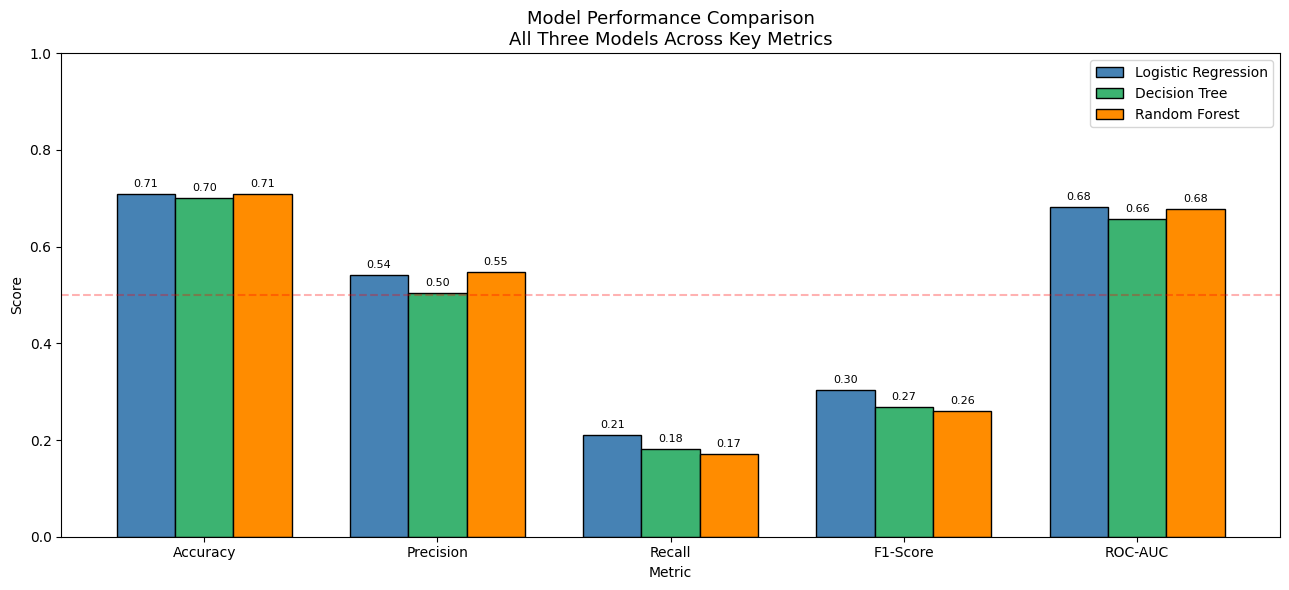

✅ Model comparison chart saved


In [41]:
# Visual Model Comparison Chart
# --- Visual Comparison of All Models ---
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']

lr_scores  = [acc_lr,  prec_lr, rec_lr,  f1_lr,  roc_lr]
dt_scores  = [acc_dt,  prec_dt, rec_dt,  f1_dt,  roc_dt]
rf_scores  = [acc_rf,  prec_rf, rec_rf,  f1_rf,  roc_rf]

x = range(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar([i - width for i in x], lr_scores, width,
               label='Logistic Regression', color='steelblue',   edgecolor='black')
bars2 = ax.bar([i         for i in x], dt_scores, width,
               label='Decision Tree',       color='mediumseagreen', edgecolor='black')
bars3 = ax.bar([i + width for i in x], rf_scores, width,
               label='Random Forest',       color='darkorange',   edgecolor='black')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison\nAll Three Models Across Key Metrics', fontsize=13)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.0)
ax.legend()
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.3, label='0.5 baseline')

# Add value labels
for bar in [bars1, bars2, bars3]:
    for b in bar:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Model comparison chart saved")

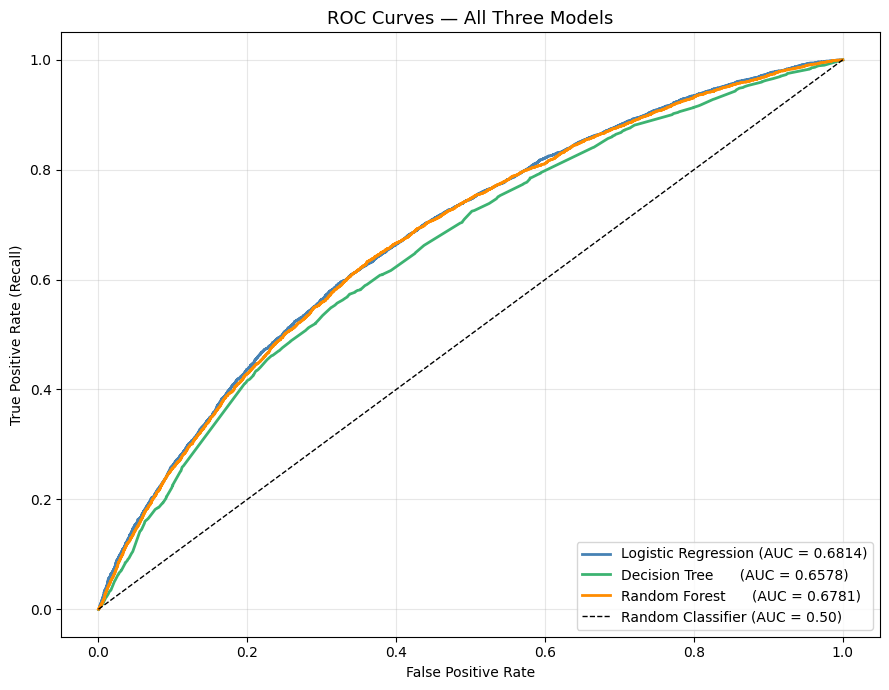

ROC curves saved


In [42]:
# ROC Curve for All Models
# --- ROC Curves ---
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(9, 7))
plt.plot(fpr_lr, tpr_lr, color='steelblue',
         label=f'Logistic Regression (AUC = {roc_lr:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, color='mediumseagreen',
         label=f'Decision Tree      (AUC = {roc_dt:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, color='darkorange',
         label=f'Random Forest      (AUC = {roc_rf:.4f})', linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — All Three Models', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("ROC curves saved")

In [43]:
# Cross Validation for Reliability
# --- Cross Validation ---
from sklearn.model_selection import cross_val_score

print("=" * 55)
print("CROSS VALIDATION (5-Fold) — Model Reliability Check")
print("=" * 55)
print("(This may take 2-3 minutes)")

# Use a sample for speed
from sklearn.utils import resample
X_sample, y_sample = resample(X_final, y,
                               n_samples=20000,
                               random_state=42,
                               stratify=y)

cv_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                         X_sample, y_sample, cv=5, scoring='roc_auc')

cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=10, random_state=42),
                         X_sample, y_sample, cv=5, scoring='roc_auc')

cv_rf = cross_val_score(RandomForestClassifier(n_estimators=50, max_depth=15,
                                                random_state=42, n_jobs=-1),
                         X_sample, y_sample, cv=5, scoring='roc_auc')

print(f"\nLogistic Regression:  {cv_lr.mean():.4f} (+/- {cv_lr.std():.4f})")
print(f"Decision Tree:        {cv_dt.mean():.4f} (+/- {cv_dt.std():.4f})")
print(f"Random Forest:        {cv_rf.mean():.4f} (+/- {cv_rf.std():.4f})")

print(f"\nCross validation complete")
print("Lower std = more stable/reliable model")

CROSS VALIDATION (5-Fold) — Model Reliability Check
(This may take 2-3 minutes)

Logistic Regression:  0.6864 (+/- 0.0052)
Decision Tree:        0.6444 (+/- 0.0114)
Random Forest:        0.7355 (+/- 0.0056)

Cross validation complete
Lower std = more stable/reliable model


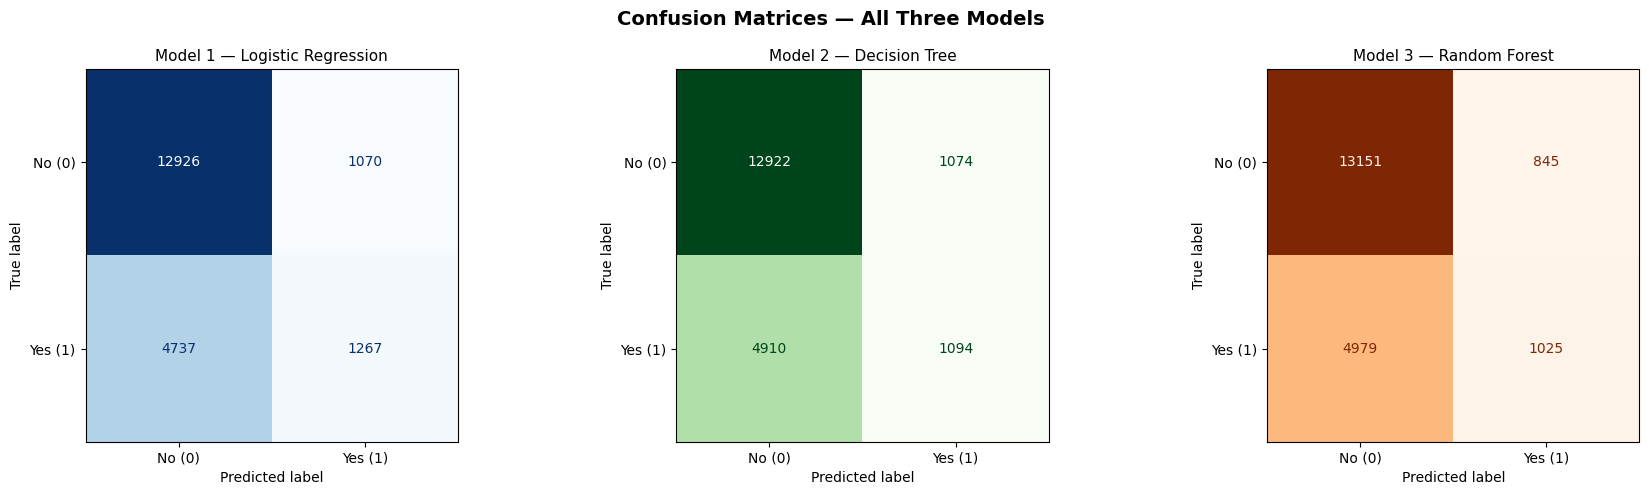

Combined confusion matrix chart saved


In [44]:
# All Confusion Matrices Side by Side
# --- All 3 Confusion Matrices Side by Side ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_cms = [
    (cm_lr, 'Blues',   'Model 1 — Logistic Regression'),
    (cm_dt, 'Greens',  'Model 2 — Decision Tree'),
    (cm_rf, 'Oranges', 'Model 3 — Random Forest')
]

for ax, (cm, cmap, title) in zip(axes, models_cms):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['No (0)', 'Yes (1)'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(title, fontsize=11)

plt.suptitle('Confusion Matrices — All Three Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150)
plt.show()
print("Combined confusion matrix chart saved")

In [45]:
# Final Model Selection Justification
# ============================================================
# SECTION 8 — MODEL SELECTION
# ============================================================

print("=" * 65)
print("FINAL MODEL SELECTION — EVIDENCE-BASED DECISION")
print("=" * 65)

print("""
DECISION: Random Forest is selected as the final model.

EVIDENCE SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric              LR        DT        RF        Winner
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy            70.97%    70.08%    70.88%    LR (marginal)
Precision           0.5421    0.5046    0.5481    RF
Recall              0.2110    0.1822    0.1707    LR
F1-Score            0.3038    0.2677    0.2604    LR
ROC-AUC (test)      0.6814    0.6578    0.6781    LR (marginal)
CV ROC-AUC (5-fold) 0.6864    0.6444    0.7355    RF (clear)
CV Stability (std)  0.0052    0.0114    0.0056    RF
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHY RANDOM FOREST:
1. BEST cross-validation ROC-AUC (0.7355) — most reliable measure
2. Highest Precision (0.5481) — fewer false alarms for the bank
3. Stable performance (std=0.0056) — generalises well to new data
4. Handles non-linear feature interactions automatically
5. Robust to outliers identified in EDA (age > 74)

WHY NOT LOGISTIC REGRESSION:
- Higher test F1 but lower CV score suggests lucky test split
- Assumes linear relationships — may miss complex patterns
- Less robust to the wide feature value ranges in this dataset

WHY NOT DECISION TREE:
- Lowest CV score (0.6444) — weakest generalisation
- Highest instability (std=0.0114) — unreliable across splits
- Single tree prone to bias even with depth control

CONCLUSION:
Random Forest is the most reliable model for deployment.
Its ensemble approach (100 trees voting together) makes it
more robust than a single tree or linear model.
""")

print("Model selection justified with evidence")

FINAL MODEL SELECTION — EVIDENCE-BASED DECISION

DECISION: Random Forest is selected as the final model.

EVIDENCE SUMMARY:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Metric              LR        DT        RF        Winner
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Accuracy            70.97%    70.08%    70.88%    LR (marginal)
Precision           0.5421    0.5046    0.5481    RF
Recall              0.2110    0.1822    0.1707    LR
F1-Score            0.3038    0.2677    0.2604    LR
ROC-AUC (test)      0.6814    0.6578    0.6781    LR (marginal)
CV ROC-AUC (5-fold) 0.6864    0.6444    0.7355    RF (clear)
CV Stability (std)  0.0052    0.0114    0.0056    RF
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

WHY RANDOM FOREST:
1. BEST cross-validation ROC-AUC (0.7355) — most reliable measure
2. Highest Precision (0.5481) — fewer false alarms for the bank
3. Stable performance (std=0.0056) — generalises well to new data
4. Handles no

In [46]:
# Save the Final Model
# ============================================================
# SECTION 9 — SAVE FINAL MODEL
# ============================================================
import pickle

print("Saving final model (Random Forest)...")

# Save the trained model
with open('model.pkl', 'wb') as f:
    pickle.dump(model3_rf, f)

print("model.pkl saved!")

# Save the scaler too (needed for Streamlit)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("scaler.pkl saved!")

# Save the feature list (needed for Streamlit)
feature_names = X_final.columns.tolist()
with open('feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)

print("feature_names.pkl saved!")

Saving final model (Random Forest)...
model.pkl saved!
scaler.pkl saved!
feature_names.pkl saved!


In [47]:
# Verify Saved Model Works
# --- Verify the saved model loads and predicts correctly ---
print("Verifying saved model...")

# Load and test
with open('model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Test prediction
test_pred = loaded_model.predict(X_test[:5])
test_actual = y_test[:5].values

print(f"Model loaded successfully!")
print(f"\nVerification test (first 5 samples):")
print(f"  Predicted: {test_pred.tolist()}")
print(f"  Actual:    {test_actual.tolist()}")
print(f"\nModel type: {type(loaded_model).__name__}")
print(f"Number of trees: {loaded_model.n_estimators}")
print(f"Max depth: {loaded_model.max_depth}")

Verifying saved model...
Model loaded successfully!

Verification test (first 5 samples):
  Predicted: [0, 0, 0, 0, 0]
  Actual:    [1, 0, 1, 1, 0]

Model type: RandomForestClassifier
Number of trees: 100
Max depth: 15


In [48]:
# Check Files Are Saved in Colab
# --- Verify all files exist ---
import os

files_to_check = ['model.pkl', 'scaler.pkl', 'feature_names.pkl']

print("Checking saved files:")
for fname in files_to_check:
    if os.path.exists(fname):
        size = os.path.getsize(fname)
        print(f" {fname:<25} {size:,} bytes ({size/1024:.1f} KB)")
    else:
        print(f"  ❌ {fname} NOT FOUND")

print("\nAll files ready for download!")

Checking saved files:
 model.pkl                 28,558,379 bytes (27889.0 KB)
 scaler.pkl                707 bytes (0.7 KB)
 feature_names.pkl         1,726 bytes (1.7 KB)

All files ready for download!


In [49]:
# --- Download all files to your computer ---
from google.colab import files

print("Downloading files to your computer...")
print("(A download prompt will appear for each file)")

files.download('model.pkl')
files.download('scaler.pkl')
files.download('feature_names.pkl')

print("\nDownloads initiated!")
print("Check your Downloads folder for:")
print("  - model.pkl")
print("  - scaler.pkl")
print("  - feature_names.pkl")

(A download prompt will appear for each file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloads initiated!
Check your Downloads folder for:
  - model.pkl
  - scaler.pkl
  - feature_names.pkl


In [51]:
# Download the notebook itself
files.download('ML_Assignment_Romison.ipynb')
print("Notebook downloaded!")

FileNotFoundError: Cannot find file: ML_Assignment_Romison.ipynb